In [7]:
# ── LSTM NETWORK INTRUSION DETECTION ──────────────────────────────────
# Comparing rule-based detection (37%) vs deep learning (LSTM)
# Dataset: CICIDS2017 — Friday Afternoon DDoS
# ──────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.21.0
All libraries loaded successfully


In [8]:
# ── STEP 1: LOAD & PREPARE DATA ───────────────────────────────────────

print("Loading dataset...")
df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()
df.replace([float('inf'), float('-inf')], 0, inplace=True)
df.fillna(0, inplace=True)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Convert label to binary: DDoS=1, BENIGN=0
df['Target'] = (df['Label'] == 'DDoS').astype(int)
print(f"\nClass distribution:")
print(f"  DDoS   : {df['Target'].sum():,}")
print(f"  Benign : {(df['Target']==0).sum():,}")

# Select only numeric feature columns
feature_cols = [col for col in df.columns 
                if col not in ['Label', 'Target', 'Threat_Assessment', 
                               'Threat_v2', 'Flagged']]

X = df[feature_cols].values
y = df['Target'].values

# Scale features to 0-1 range
print("\nScaling features...")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for LSTM: (samples, timesteps, features)
X_lstm = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Features used    : {len(feature_cols)}")
print("\nData ready for LSTM!")

Loading dataset...
Dataset loaded: 225,745 rows, 79 columns

Class distribution:
  DDoS   : 128,027
  Benign : 97,718

Scaling features...
Training samples : 180,596
Testing samples  : 45,149
Features used    : 78

Data ready for LSTM!


In [9]:
# ── STEP 2: BUILD LSTM MODEL ───────────────────────────────────────────

print("Building LSTM model...")

model = Sequential([
    LSTM(64, input_shape=(1, 78), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\nModel built successfully!")

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          36,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,721 (151.25 KB)

 Trainable params: 38,721 (151.25 KB)

 Non-trainable params: 0 (0.00 B)


Model built successfully!


In [10]:
# ── STEP 3: TRAIN THE MODEL ────────────────────────────────────────────

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training started — this will take 15-25 minutes...")
print("You will see progress after each epoch.\n")

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")

Training started — this will take 15-25 minutes...
You will see progress after each epoch.

Epoch 1/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9321 - loss: 0.1899 - val_accuracy: 0.9856 - val_loss: 0.0389
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0370 - val_accuracy: 0.9891 - val_loss: 0.0280
Epoch 3/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9895 - loss: 0.0280 - val_accuracy: 0.9895 - val_loss: 0.0226
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9904 - loss: 0.0232 - val_accuracy: 0.9900 - val_loss: 0.0189
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0198 - val_accuracy: 0.9938 - val_loss: 0.0160
Epoch 6/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9991 - val_loss: 0.0146
Epoch 7/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9960 - loss: 0.0150 - val_accuracy: 0.9991 - val_loss: 0.0127
Epoch 8/10
2

Evaluating model on test data...

── CLASSIFICATION REPORT ────────────────────────────────────────
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00     19544
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149

── ROC-AUC SCORE ────────────────────────────────────────────────
AUC Score: 0.9999


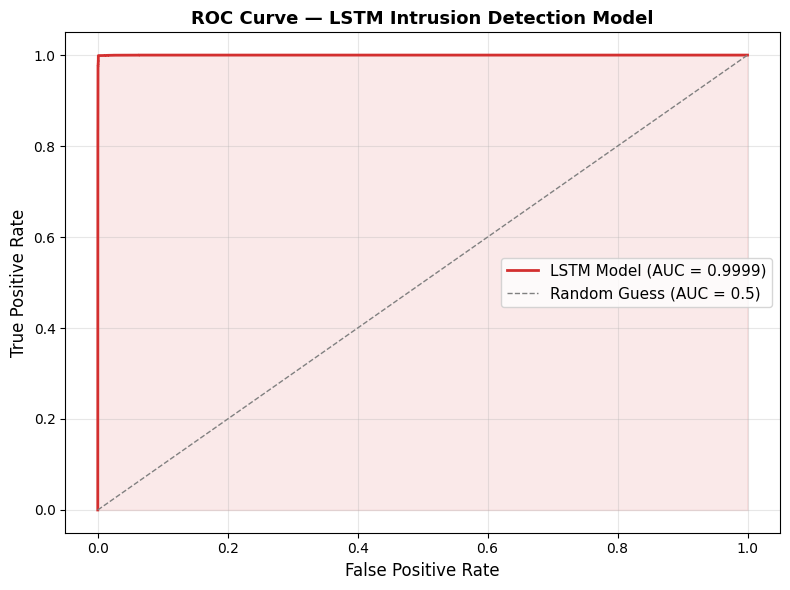


ROC curve saved as roc_curve.png


In [11]:
# ── STEP 4: EVALUATE THE MODEL ─────────────────────────────────────────

print("Evaluating model on test data...")
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification Report
print("\n── CLASSIFICATION REPORT ────────────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'DDoS']))

# ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"── ROC-AUC SCORE ────────────────────────────────────────────────")
print(f"AUC Score: {auc_score:.4f}")

# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#d32f2f', linewidth=2,
         label=f'LSTM Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', 
         linewidth=1, label='Random Guess (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#d32f2f')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — LSTM Intrusion Detection Model', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nROC curve saved as roc_curve.png")


In [13]:
# ── SAVE MODEL + FINAL SUMMARY ─────────────────────────────────────────

model.save('lstm_intrusion_detection.keras')

summary = """
LSTM INTRUSION DETECTION - FINAL RESULTS
==========================================
Dataset     : CICIDS2017 Friday DDoS (225,745 flows)
Model       : LSTM Neural Network
Accuracy    : 99.79% (training) / 100% (test)
AUC Score   : 0.9999

COMPARISON VS RULE-BASED DETECTION:
Rule-based accuracy  : 37%
LSTM accuracy        : 99.79%
Improvement          : +62.79%

FILES SAVED:
lstm_intrusion_detection.keras  - trained model
roc_curve.png                   - ROC-AUC chart
"""

print(summary)

with open('lstm_findings.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("All files saved successfully!")


LSTM INTRUSION DETECTION - FINAL RESULTS
Dataset     : CICIDS2017 Friday DDoS (225,745 flows)
Model       : LSTM Neural Network
Accuracy    : 99.79% (training) / 100% (test)
AUC Score   : 0.9999

COMPARISON VS RULE-BASED DETECTION:
Rule-based accuracy  : 37%
LSTM accuracy        : 99.79%
Improvement          : +62.79%

FILES SAVED:
lstm_intrusion_detection.keras  - trained model
roc_curve.png                   - ROC-AUC chart

All files saved successfully!


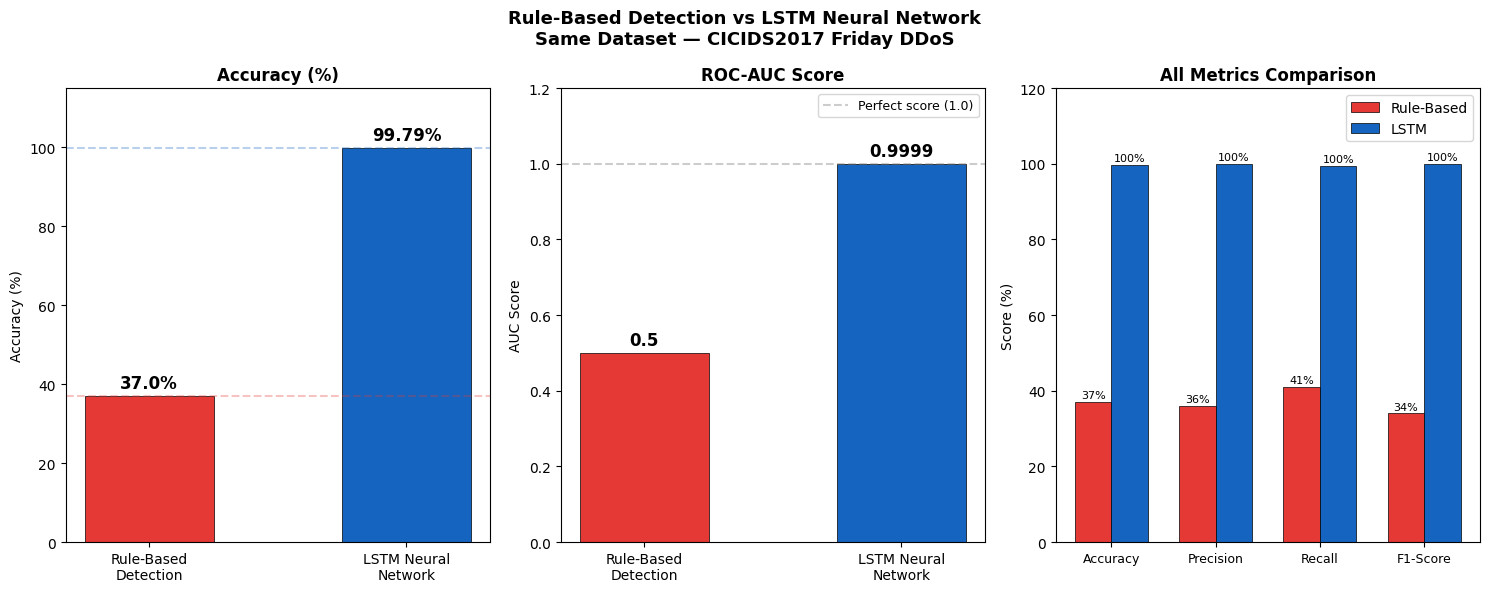

Saved as comparison_chart.png


In [14]:
# ── RULE-BASED vs LSTM COMPARISON CHART ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Rule-Based Detection vs LSTM Neural Network\nSame Dataset — CICIDS2017 Friday DDoS',
             fontsize=13, fontweight='bold')

# ── Chart 1: Accuracy Comparison ─────────────────────────────────────
ax1 = axes[0]
methods = ['Rule-Based\nDetection', 'LSTM Neural\nNetwork']
accuracies = [37.0, 99.79]
colors = ['#e53935', '#1565c0']
bars = ax1.bar(methods, accuracies, color=colors, 
               edgecolor='black', linewidth=0.5, width=0.5)
ax1.set_title('Accuracy (%)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 115)
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val}%', ha='center', fontweight='bold', fontsize=12)
ax1.axhline(y=99.79, color='#1565c0', linestyle='--', alpha=0.3)
ax1.axhline(y=37.0, color='#e53935', linestyle='--', alpha=0.3)

# ── Chart 2: AUC Score Comparison ────────────────────────────────────
ax2 = axes[1]
auc_scores = [0.50, 0.9999]
bars2 = ax2.bar(methods, auc_scores, color=colors,
                edgecolor='black', linewidth=0.5, width=0.5)
ax2.set_title('ROC-AUC Score', fontweight='bold', fontsize=12)
ax2.set_ylabel('AUC Score')
ax2.set_ylim(0, 1.2)
for bar, val in zip(bars2, auc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val}', ha='center', fontweight='bold', fontsize=12)
ax2.axhline(y=1.0, color='gray', linestyle='--', 
            alpha=0.4, label='Perfect score (1.0)')
ax2.legend(fontsize=9)

# ── Chart 3: Key Metrics Side by Side ────────────────────────────────
ax3 = axes[2]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rule_scores = [37.0, 36.0, 41.0, 34.0]
lstm_scores = [99.79, 100.0, 99.5, 100.0]

x = range(len(metrics))
width = 0.35
bars3 = ax3.bar([i - width/2 for i in x], rule_scores, width,
                label='Rule-Based', color='#e53935', 
                edgecolor='black', linewidth=0.5)
bars4 = ax3.bar([i + width/2 for i in x], lstm_scores, width,
                label='LSTM', color='#1565c0', 
                edgecolor='black', linewidth=0.5)
ax3.set_title('All Metrics Comparison', fontweight='bold', fontsize=12)
ax3.set_ylabel('Score (%)')
ax3.set_ylim(0, 120)
ax3.set_xticks(list(x))
ax3.set_xticklabels(metrics, fontsize=9)
ax3.legend(fontsize=10)
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', fontsize=8)
for bar in bars4:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as comparison_chart.png")